#**GDG TASK 4**

In the task for this week, we will be exploring another ML Models like Decision Tree, Random Forest and Naive Bayes. We will also learn hyperparameter tuning using ensemble techniques (Bagging & Boosting) and Decision Tree Pruning.

**This Task has various theory questions to be answered here and there. Don't miss out on those, as they will make you'll conceptually stronger, and give a better understanding.**

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

# Decision Tree Classifier

* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

Load the titanic dataset in a pandas dataframe (download dataset from https://www.kaggle.com/c/titanic/data and store it in the "Synapse" folder initially created for the interview tasks) Note that you have to download the train and test csv files seperately

<b>Read the titanic_data.csv using pandas and show the dataframe</b>

In [66]:
import pandas as pd

In [67]:
#write code here
df=pd.read_csv('/content/train.csv')

In [68]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Visualizing hidden Details

* print the name column of the data
* notice that the word after the first comma encapsulates the title of the person (Mr., Mrs, etc)
* extract the title using regular expression (help given below in the code)
* store the title in a new column in the dataframe. Name the column : Title

In [69]:
# try researching about regex
df['Name']

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [70]:
import re
df['Title'] = df['Name'].str.extract(r', (\w+\.)', expand=False)

In [71]:
df['Title']

,Title
0,Mr.
1,Mrs.
2,Miss.
3,Mrs.
4,Mr.
...,...
886,Rev.
887,Miss.
888,Miss.
889,Mr.


In [72]:
df['Title'].unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Don.', 'Rev.', 'Dr.', 'Mme.',
       'Ms.', 'Major.', 'Lady.', 'Sir.', 'Mlle.', 'Col.', 'Capt.', nan,
       'Jonkheer.'], dtype=object)

### Removing unnecessary columns
*   The columns PassengerId and Ticket play no logical role in being related to the survival of a passenger. Hence we will remove them.
*   We will also remove the Name column as we have done feature extraction and obtained titles instead. (test set might have extra titles which are not in the train set. Think about how we would consider them. This however doesn't affect task 1's objective)

In [73]:
#write code here
df.drop(['PassengerId', 'Ticket', 'Name'], axis=1, inplace=True)

### Nan analysis
*   write code to find the percentage of Nans in each column and visualize it in a tabular format
*   remove any column having more than 50% Nans as they would be of no use

In [74]:
#write code here
#write code here
percentage_of_nan = (df.isna().sum())/len(df)*100
percentage_of_nan

,0
Survived,0.000000
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Cabin,77.104377
Embarked,0.224467
Title,0.112233


In [75]:
#write code here
df.drop('Cabin', axis=1, inplace=True)

*   Fill Nans in the Embark column with the statistical mode
*   Fill Nans in the Age column with it's statistical mean

In [76]:
#write code here
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)

<ipython-input-76-148ea805eb77>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
<ipython-input-76-148ea805eb77>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

### Adding features to the dataset
*   Read the kaggle link (titanic dataset) provided above and see what the two columns SibSP and Parch signify
*   Using that create a new column called **Family_members**
*   Fill it with the sum of SibSP and Parch

In [77]:
#write code here
df['Family_members'] = df['SibSp'] + df['Parch']

In [78]:
#Normalize the columns ("Age", "Fare", "Family_members")
df['Age'] = (df['Age'] - df['Age'].min()) / (df['Age'].max() - df['Age'].min())
df['Fare'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max() - df['Fare'].min())
df['Family_members'] = (df['Family_members'] - df['Family_members'].min()) / (df['Family_members'].max() - df['Family_members'].min())


In [79]:
#apply one hot encoding on the columns ('Pclass','Sex','Title','Embarked')
df = pd.get_dummies(df, columns=['Pclass','Sex','Title','Embarked']).astype(int)

In [80]:
df

,Survived,Age,SibSp,Parch,Fare,Family_members,Pclass_1,Pclass_2,Pclass_3,Sex_female,...,Title_Mlle.,Title_Mme.,Title_Mr.,Title_Mrs.,Title_Ms.,Title_Rev.,Title_Sir.,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
1,1,0,1,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
887,1,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
888,0,0,1,2,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
889,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0


<b>extract the y label (survived) from the dataframe and store it in a new variable</b>

In [81]:
#write code here
df_test = df['Survived']

<b>remove the y_label (survived) from the dataframe</b>

In [82]:
#write code here
df_train = df.drop('Survived',axis=1)

<b>Split the data into train and test. (do a split in the ratio 70:30)</b>

In [83]:
#write code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_train, df_test, test_size=0.3, random_state=42)

In [84]:
y_train.value_counts(normalize=True)

,proportion
Survived,
0,0.629213
1,0.370787


In [85]:
y_test.value_counts(normalize=True)

,proportion
Survived,
0,0.585821
1,0.414179


<b>Now that you have the entire preprocessed and split data, implement the decision tree algorithm from sklearn and fit it to this dataset</b> <br>



In [86]:
#write code here
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

<b>Print the Model Accuracy</b>

In [87]:
#write code here
from sklearn.metrics import accuracy_score
y_pred = decision_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7686567164179104


## Explain: Give a Real life Example where Decision Tree Classifier can be used.

Ans:

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [88]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 4, 8, 12],
    'min_samples_split': [1, 2, 3],
    'min_samples_leaf': [3, 6, 9]
}

grid_search = GridSearchCV(decision_tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [None, 4, 8, 12],
                         'min_samples_leaf': [3, 6, 9],
                         'min_samples_split': [1, 2, 3]},
             scoring='accuracy')

In [89]:
best_model = grid_search.best_estimator_
best_accuracy = grid_search.best_score_
best_model, best_accuracy

(DecisionTreeClassifier(min_samples_leaf=6, random_state=42),
 0.836283870967742)

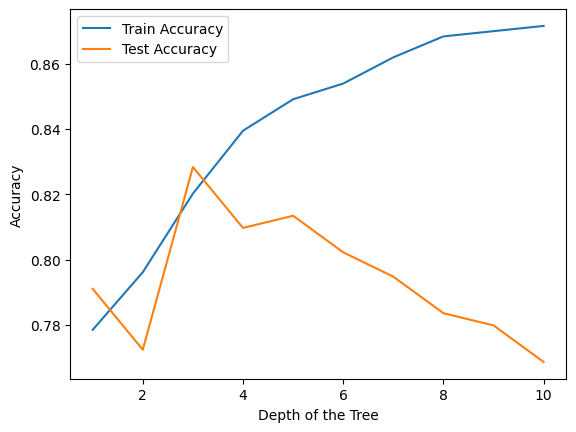

In [90]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
depth_range = range(1, 11)
train_accuracies = []
test_accuracies = []
for depth in depth_range:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

plt.plot(depth_range, train_accuracies, label='Train Accuracy')
plt.plot(depth_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Depth of the Tree')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



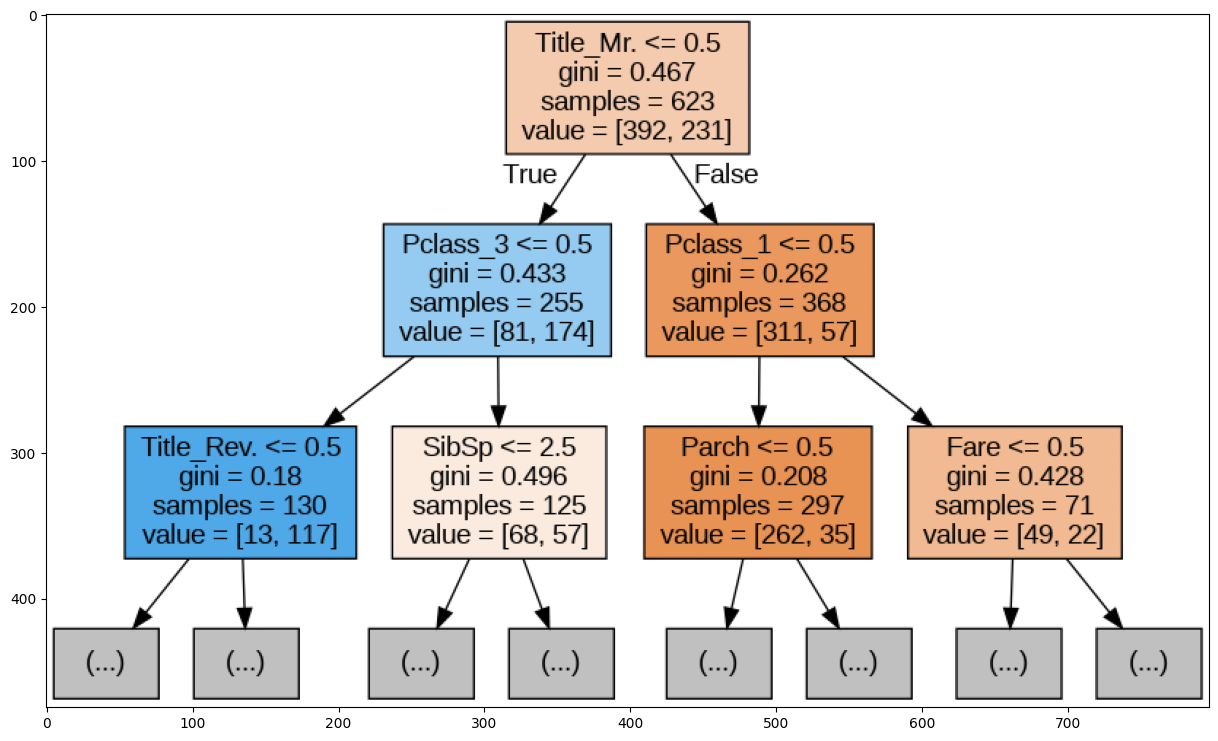

In [91]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(decision_tree, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(15,15))
plt.imshow(image)

<b>print the test accuracy and train accuracy here</b>

In [94]:
print("Test Accuracy:", accuracy)
print("Train Accuracy:", accuracy_score(y_train, best_model.predict(X_train)))

Test Accuracy: 0.7686567164179104
Train Accuracy: 0.8459069020866774


## Explain: What is your understanding of the charts you made above?

Ans: In the Train and Test Accuracy v/s Tree Depth, we can infer that the accuracy increases for training dataset continuously uptil the depth of tree reaches 10. But incase of test dataset, it initially decreases uptil the tree depth is 2. Later on, it increases uptil the depth of tree is approxiamtely 3 and again it starts decreasing. Since the accuracy differs drastically after tree depth of 3, indicating the model overfits. Hence, tree depth of 3 is optimum for the model.

In the tree image, the decision tree aims to predict passenger survival starting by distinguishing titles, prioritizing "Mr." as a risk factor. Further splits consider passenger class, with lower classes being more dangerous. Within these classes, additional factors like other titles, family size, and fare are considered. This suggests that a combination of social status, family connections, and economic factors influenced survival chances.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [95]:
# Write a code to implement naive bayes algorithm, and give the accuracy for the same
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)
y_pred = naive_bayes.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8022388059701493


## Explain: What is the difference between Decision Tree Classifier and Naive Bayes algorithm?

1. **Model Type**:
   - **Decision Tree**: A non-parametric model that recursively splits data based on feature values to make predictions.
   - **Naive Bayes**: A probabilistic model that uses Bayes' Theorem, assuming features are conditionally independent given the class label.

2. **Interpretability**:
   - **Decision Tree**: Highly interpretable; the tree structure allows for easy visualization and understanding of the decision-making process.
   - **Naive Bayes**: Less interpretable in terms of rules, but you can interpret the model through the probabilities of features for each class.

3. **Handling of Features**:
   - **Decision Tree**: Handles both numerical and categorical data and does not require feature scaling.
   - **Naive Bayes**: Works better with categorical features and assumes independence among features. For continuous features, it typically assumes a specific distribution (e.g., Gaussian).

4. **Overfitting and Complexity**:
   - **Decision Tree**: Prone to overfitting if the tree is too deep or not pruned properly. It can be computationally expensive for large datasets.
   - **Naive Bayes**: Less prone to overfitting, particularly with high-dimensional data, and is computationally efficient.

5. **Performance with Correlated Features**:
   - **Decision Tree**: Can handle correlated features well, as it recursively splits based on feature interactions.
   - **Naive Bayes**: Struggles with correlated features due to its assumption of conditional independence.

6. **Use Cases**:
   - **Decision Tree**: Ideal for tasks requiring complex decision boundaries, like fraud detection, customer segmentation, and medical diagnosis.
   - **Naive Bayes**: Best suited for tasks with high-dimensional data, such as text classification, spam filtering, and sentiment analysis.

## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [96]:
#write code here
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

randomforest_classifier = RandomForestClassifier()
randomforest_classifier.fit(X_train, y_train)

RandomForestClassifier()

In [97]:
n_estimators = [1,2,4,8,16,32,64,100,200]
max_depth = [1,2,4,8,16,32,64,None]
param_grid = {'n_estimators': n_estimators, 'max_depth': max_depth}

grid_search = GridSearchCV(estimator=randomforest_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [1, 2, 4, 8, 16, 32, 64, None],
                         'n_estimators': [1, 2, 4, 8, 16, 32, 64, 100, 200]})

In [98]:
best_model = grid_search.best_estimator_
best_accuracy = grid_search.best_score_
best_model, best_accuracy

(RandomForestClassifier(max_depth=8, n_estimators=8), 0.8298580645161291)

n_estimators: 1, Train Accuracy: 0.8491171749598716, Test Accuracy: 0.7574626865671642
n_estimators: 2, Train Accuracy: 0.85553772070626, Test Accuracy: 0.7910447761194029
n_estimators: 4, Train Accuracy: 0.8683788121990369, Test Accuracy: 0.7910447761194029
n_estimators: 8, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7835820895522388
n_estimators: 16, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7985074626865671
n_estimators: 32, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7985074626865671
n_estimators: 64, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7985074626865671
n_estimators: 100, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7985074626865671
n_estimators: 200, Train Accuracy: 0.8715890850722311, Test Accuracy: 0.7985074626865671


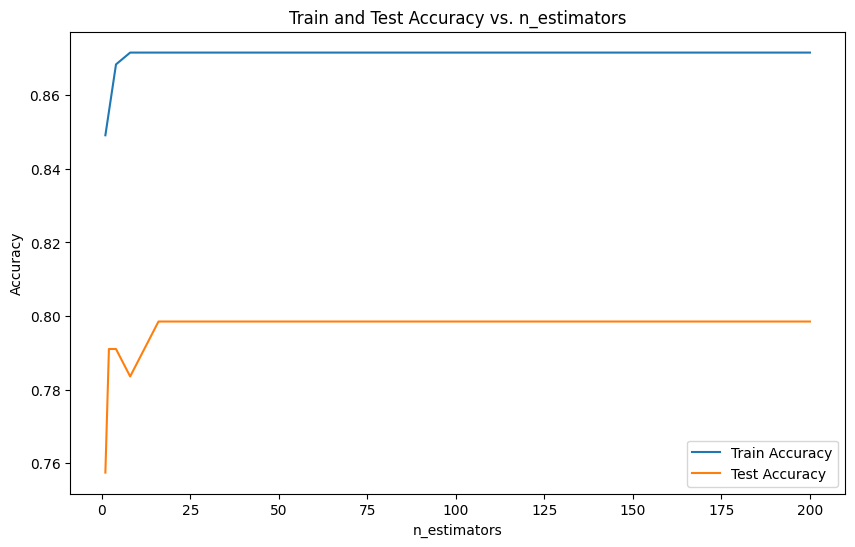

In [99]:
train_results = []
test_results = []

for n_estimator in n_estimators:
    randomforest_classifier = RandomForestClassifier(n_estimators=n_estimator, random_state=42)
    randomforest_classifier.fit(X_train, y_train)
    train_pred = randomforest_classifier.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_results.append(train_acc)
    test_pred = randomforest_classifier.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_results.append(test_acc)
    print(f"n_estimators: {n_estimator}, Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")

plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_results, label='Train Accuracy')
plt.plot(n_estimators, test_results, label='Test Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy vs. n_estimators')
plt.legend()
plt.show()

## Explain: Under what condition will Random Forest and Decision Trees have the same accuracy?

Ans:

1. **One Tree in the Random Forest**: If the Random Forest consists of only a single tree, it behaves the same as a single Decision Tree, and their accuracies will match.
   
2. **Overfitting**: If both the Random Forest and the Decision Tree are overfitted (e.g., too many trees or overly deep trees), they may have similar performance on training data, resulting in the same accuracy.

3. **Simple Data**: If the data is simple enough that a single Decision Tree already captures all patterns, the Random Forest may not provide additional benefits, and both models will have the same accuracy.


## Extra - BaggingClassifier

In [100]:
#write a code to implement BaggingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier

bagging_classifier = BaggingClassifier()
bagging_classifier.fit(X_train, y_train)

BaggingClassifier()

In [101]:
y_pred = bagging_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7761194029850746


## Explain: What is the difference between Random Forest and Bagging Classifier

Ans: Random Forest Classifier and Bagging Classifier are both ensemble learning techniques, meaning they combine multiple models to make better predictions.

Bagging Classifer trains multiple models on different random subsets of data, where in the end the final prediction is made by averaging the predictions of all the models or using majority vote.The main aim is to reduce variance and avoid overfitting by averaging predictions from multiple models. It can have any classifer as base model.

Random Forest classifier is a type of bagging method where it uses random subsets of the data also randomly selecting a set of features for each decision tree making splits. This makes each tree more independent and help reduce overfitting. The main aim is to make tree less correlates with each other by random feature selection. In Random forest, only decision trees are used as base models.

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [102]:
#write code here
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

adaboost_classifier = AdaBoostClassifier(n_estimators=50,learning_rate=0.25)
adaboost_classifier.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(learning_rate=0.25)

In [103]:
y_pred = adaboost_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8283582089552238


## Explain: What is the difference between Bagging and Boosting?

Ans: **Bagging** involves training multiple models independently using different random subsets of the data. Each model is trained on a random sample of the data, and the final prediction is made by combining the results—either by voting for classification tasks or averaging for regression tasks. The goal of bagging is to reduce the model's variance and avoid overfitting, making it more stable. This method works well with models like Decision Trees that have high variance. **Random Forest** is a popular example of bagging.

**Boosting**, on the other hand, builds models one after the other, with each new model trying to correct the mistakes made by the previous ones. In boosting, the mistakes (or misclassified data points) are given more attention in the next model, so the model learns from its errors. The final prediction is made by combining all the models, where each model’s prediction is weighted according to its accuracy. Boosting aims to improve the overall performance of weak models. **AdaBoost** and **Gradient Boosting** are well-known boosting algorithms. Unlike bagging, boosting can be more sensitive to noisy data because it focuses on correcting errors, which can lead to overfitting if not controlled properly.

### 3. Pruning Techniques

https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107

In [104]:
#write code here
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import make_scorer, accuracy_score, classification_report
from sklearn.model_selection import ParameterGrid, GridSearchCV

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)




DecisionTreeClassifier(random_state=42)

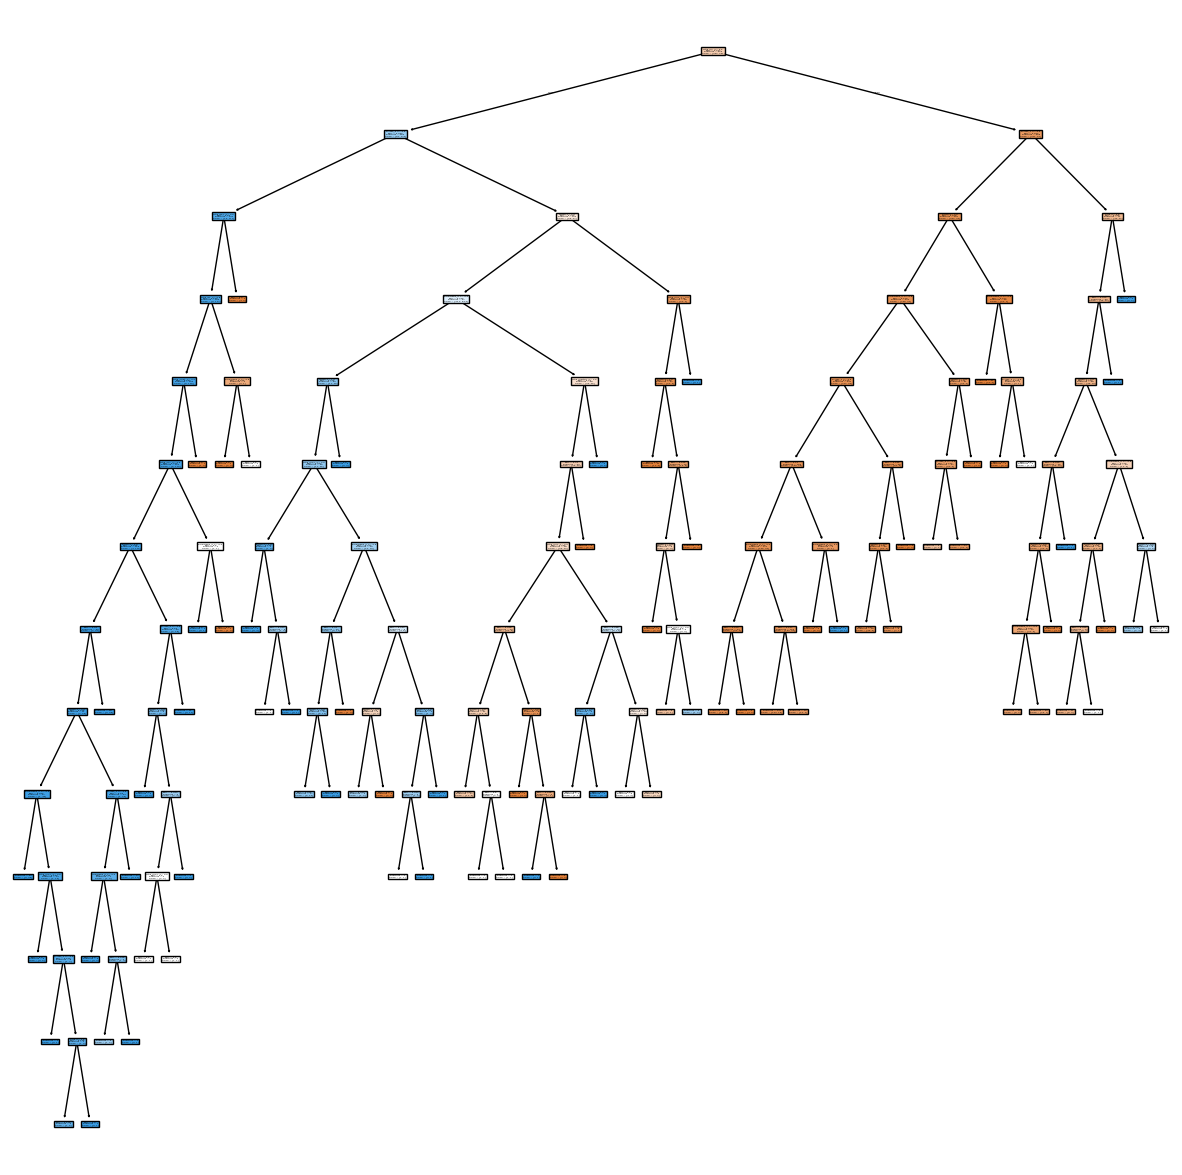

In [105]:
plt.figure(figsize=(15,15))
plot_tree(decision_tree, filled=True, feature_names=X_train.columns)
plt.show()

In [111]:
max_depth = decision_tree.get_depth()
max_depth

13

In [112]:
max_depth_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': range(1, max_depth+1)},
    scoring=make_scorer(accuracy_score),
    cv=5
)

In [113]:
max_depth_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': range(1, 14)},
             scoring=make_scorer(accuracy_score, response_method='predict'))

In [114]:
max_depth_grid_search.best_params_

{'max_depth': 5}

In [115]:
best_max_depth_tree = max_depth_grid_search.best_estimator_
best_max_depth_tree

DecisionTreeClassifier(max_depth=5, random_state=42)

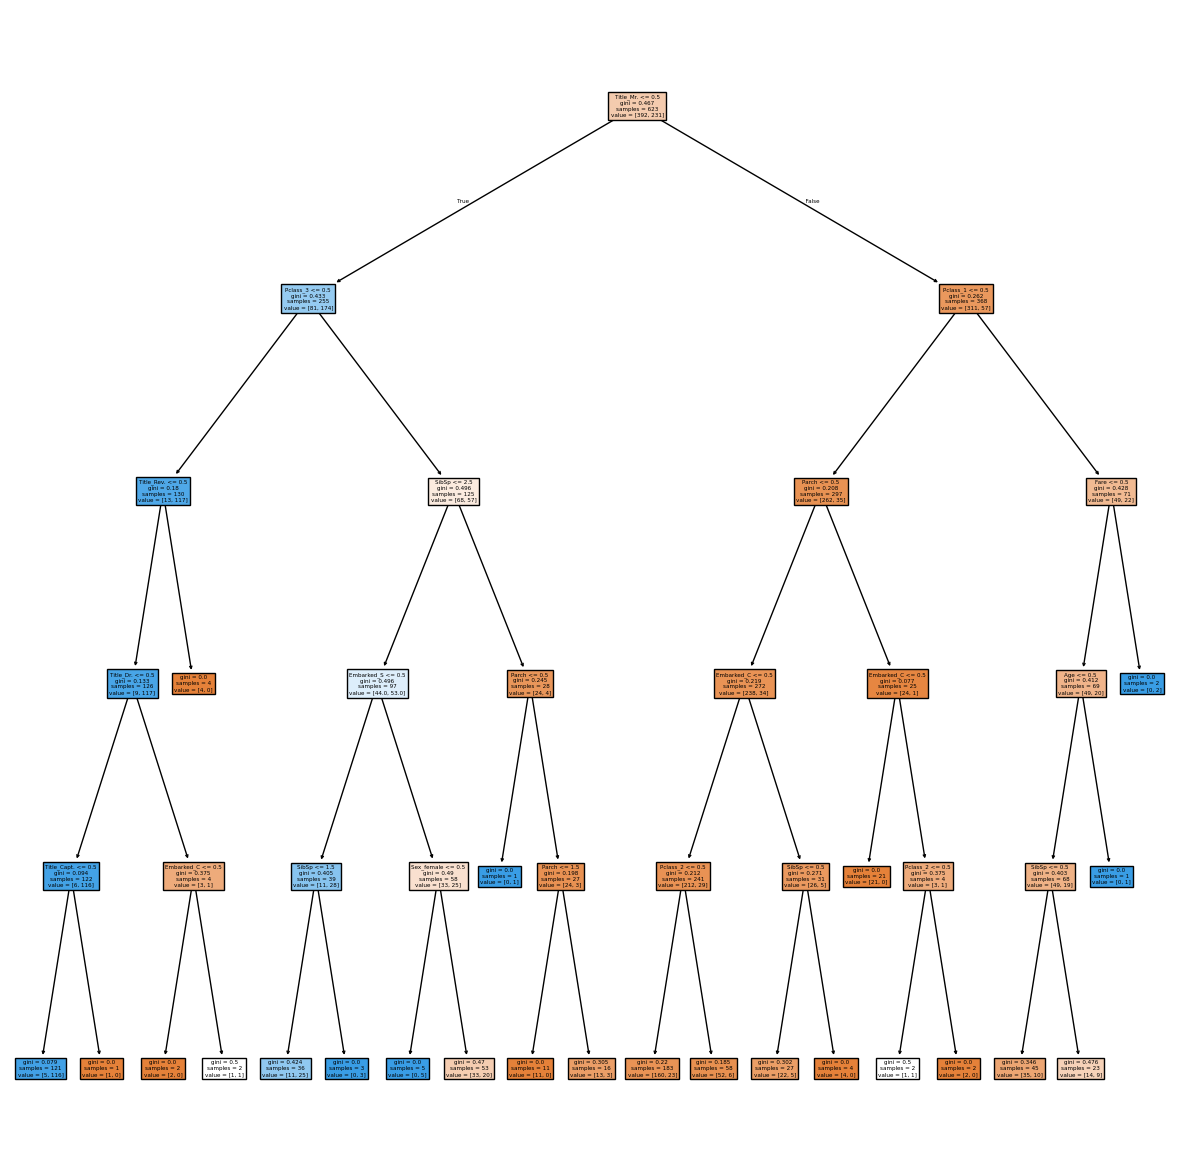

In [116]:
plt.figure(figsize=(15,15))
plot_tree(best_max_depth_tree, filled=True, feature_names=X_train.columns)
plt.show()

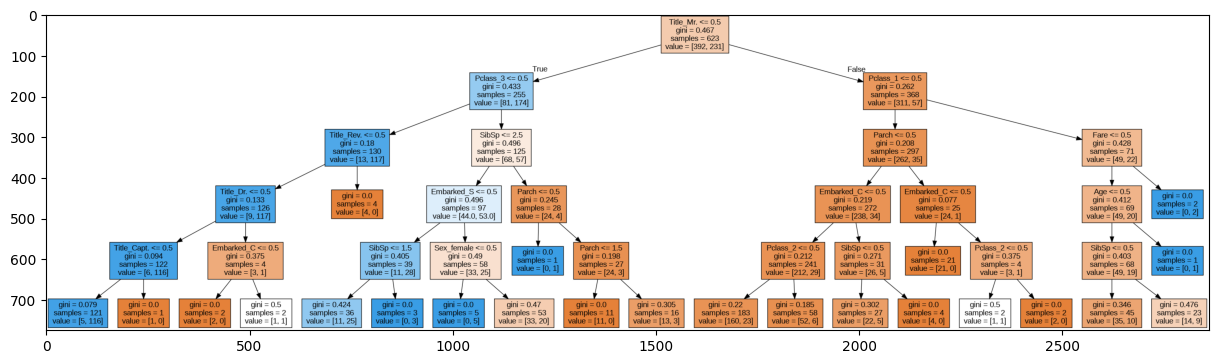

In [117]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique
from sklearn import tree
!pip install graphviz
pruning_decisionTree_img = tree.export_graphviz(best_max_depth_tree, out_file='tree.dot', feature_names=X_train.columns, max_depth=max_depth, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(15,15))
plt.imshow(image)

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

## Explain: After studying these techniques, analyse which method gives you the best accuracy and choose it as your most optimal model.

Ans: After analyzing the techniques, I believe **AdaBoost** may provide higher accuracy and better performance, particularly due to its iterative approach of focusing on difficult-to-classify instances. This method helps the model learn from its mistakes and refine its predictions, making it particularly effective for tasks where subtle patterns or imbalances in the dataset play a significant role. AdaBoost often outperforms models like **Random Forest** in these scenarios, especially when the data contains intricate patterns or when class imbalances need to be addressed effectively.


# **Compulsory Task**

Research and create a short blog on the topic of **XG Boost and AdaBoost Classifier and Regressor**.


## XGBoost vs AdaBoost: A Comparison of Two Powerful Boosting Algorithms




**XGBoost** (Extreme Gradient Boosting) is an implementation of gradient boosting designed to be highly efficient, flexible, and portable. It is an extension of traditional gradient boosting that incorporates regularization (L1 and L2), making it less prone to overfitting. XGBoost builds a series of trees sequentially, where each new tree tries to correct the errors made by the previous ones. The key advantages of XGBoost are its speed, scalability, and the ability to handle large datasets with complex structures.

XGBoost uses a gradient descent algorithm to minimize the error of each successive tree, which makes it highly effective in optimizing predictive performance. The use of **shrinkage** (learning rate) and **tree pruning** also helps improve generalization and efficiency. It’s particularly known for winning many Kaggle competitions due to its robust performance.

#### Key Features of XGBoost:
- **Regularization** to prevent overfitting
- **Handling of missing data** with an in-built mechanism
- **Parallel processing** for faster computation
- **Flexibility** in handling different loss functions for classification and regression
- **Tree pruning** for better accuracy

XGBoost is ideal for large, complex datasets where performance and efficiency are critical. It is widely used in **regression and classification tasks**, especially when dealing with imbalanced datasets or requiring high predictive accuracy. Its ability to handle missing values and work with custom loss functions makes it highly flexible and adaptable for different types of machine learning problems. XGBoost is a go-to algorithm for **Kaggle competitions**, where its speed and accuracy help in creating robust models.

------------------------------------------------------------------------

**AdaBoost** (Adaptive Boosting) is another boosting algorithm that focuses on improving the performance of weak learners. Unlike XGBoost, which builds decision trees, AdaBoost works by adjusting the weights of incorrectly predicted data points in the training set. Each new model in AdaBoost gives more weight to the samples that were misclassified by the previous model, allowing the algorithm to correct its mistakes progressively.

AdaBoost can work with any classifier, but it is typically used with decision trees (known as **stumps**, or trees with a single split). The predictions from multiple weak classifiers are then combined through a weighted average, with more emphasis on the more accurate models. Although AdaBoost is simpler and faster to implement than XGBoost, it’s more sensitive to noisy data, and it may overfit if not carefully tuned.

#### Key Features of AdaBoost:
- **Focuses on hard-to-predict instances** by adjusting sample weights
- **Combines weak learners** into a strong model
- **Simple and fast** to implement
- **Versatile** in terms of the base model (can use any classifier)
- **Sensitive to noisy data** and outliers

AdaBoost is best suited for simpler tasks where computational resources are limited, and the dataset isn’t too large. It works well for problems where the data can be classified by weak learners (such as decision stumps). If you're working with **smaller datasets** and need a simple, easy-to-implement boosting model, AdaBoost is a great choice. However, you should be cautious with noisy data, as AdaBoost can easily overfit in the presence of outliers.



# **End of Task**

